# <font size=6><b>Lec07. RNN : 순환 신경망(Recurrent Neural Network)
* https://wikidocs.net/book/2155

*  <b>입력과 출력을 시퀀스 단위로 처리하는 시퀀스(Sequence) 모델

<img src = "https://static.wikidocs.net/images/page/22886/rnn_image2_ver3.PNG" width = "500">

# <font color = red><b>  장단기 메모리(Long Short-Term Memory, LSTM)

* Vanshing Gradient 문제해결

<img src = "https://static.wikidocs.net/images/page/22888/vaniila_rnn_and_different_lstm_ver2.PNG" width = 400>

Ct 장기값(이전히든셀에서부터온 장기값), 정보를 더하거나 빼면서 아주 먼 과거의 정보도 손실 없이 현재까지 전달하는 통로 역할<br>
Wt short(바로직전의값),단기메모리

<table>
<tr>
<td>
    <b>Step 1. Forget Gate: 과거 정보를 버릴지 말지 결정하는 과정<br>
    <img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Ft1.daumcdn.net%2Fcfile%2Ftistory%2F99B7AA385C30F68708" width=600></td>
<td>
    <b>Step 2. Input Gate: 현재 정보를 저장할지 결정하는 과정<br>
    <img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Ft1.daumcdn.net%2Fcfile%2Ftistory%2F99AE0E485C30F68705" width=600></td>
</tr>
<tr>    
    <td>
        <b>Step 3. Update (cell state): 과거 cell state(Ct-1)를 새로운 state(Ct)로 업데이트 하는 과정<br>
        <img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Ft1.daumcdn.net%2Fcfile%2Ftistory%2F99A8453C5C30F68708" width=600></td>
<td>   
    <b>Step 4. Output Gate (hidden state): 어떤 출력값을 출력할지 결정하는 과정<br>
    <img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Ft1.daumcdn.net%2Fcfile%2Ftistory%2F99987F375C30F68706" width=600></td>
</tr>
</table>


| 단계 | 이름 | 주요 역할 | 핵심 수식 |
| :--- | :--- | :--- | :--- |
| **Step 1** | **Forget Gate** | 과거 정보를 버릴지 말지 결정 (망각) | $f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$ |
| **Step 2** | **Input Gate** | 현재 새로운 정보를 저장할지 결정 (입력) | $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$ <br> $\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$ |
| **Step 3** | **Update (Cell State)** | 과거 상태($C_{t-1}$)를 새로운 상태($C_t$)로 업데이트 | $C_t = f_t * C_{t-1} + i_t * \tilde{C}_t$ |
| **Step 4** | **Output Gate** | 어떤 값을 출력($h_t$)할지 결정 (출력) | $o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$ <br> $h_t = o_t * \tanh(C_t)$ |

# <font color = red><b>Intro to Recurrent Neural Networks LSTM | GRU
* https://www.kaggle.com/code/thebrownviking20/intro-to-recurrent-neural-networks-lstm-gru

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split    
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional
from tensorflow.keras.layers import Flatten, Dense, Rescaling
from tensorflow.keras.initializers import GlorotNormal    #Xavier

from tensorflow.keras.applications import MobileNetV2     #최소 이미지 크기 (32*32)

import math
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

#----------------------------------------------------------------------------------  랜덤시드 고정 
import tensorflow as tf
tf.random.set_seed(54546)
np.random.seed(54546)

#----------------------------------------------------------------------------------  EDA : 이미지로드
import os
from tensorflow.keras.utils import load_img, img_to_array
from PIL import Image
from tensorflow.keras.utils import image_dataset_from_directory

#----------------------------------------------------------------------------------  조기종료
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
    

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

## <b>공통함수

In [2]:
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real IBM Stock Price')
    plt.plot(predicted, color='blue',label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

## <b>Data Load

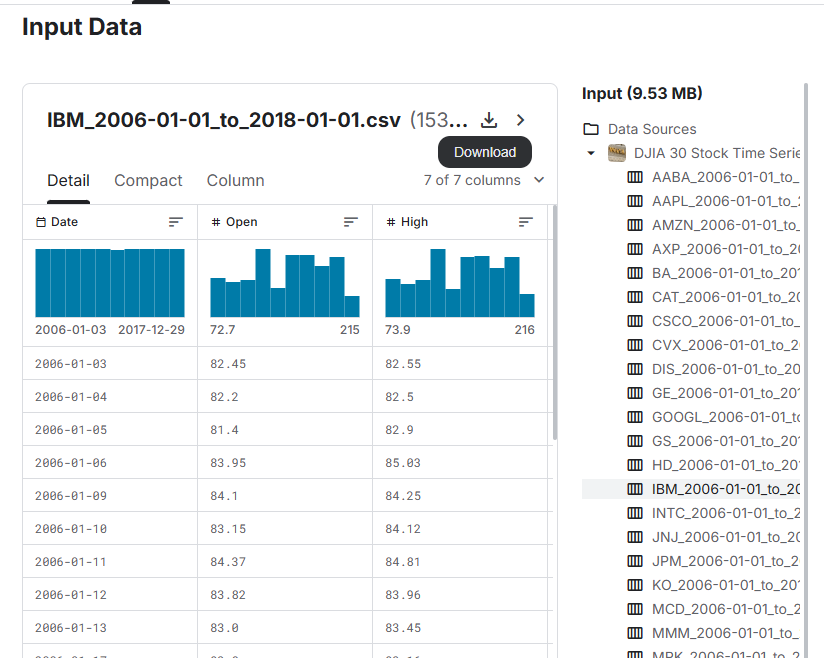

In [3]:
dataset = pd.read_csv(r'C:\IT\workspace_ptyhon\dl\dataset/IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [4]:
dataset.index.year.value_counts().sort_index() #1년에 주말빼고 ==252

Date
2006    251
2007    251
2008    253
2009    252
2010    252
2011    252
2012    250
2013    252
2014    252
2015    252
2016    252
2017    251
Name: count, dtype: int64

## <b>train_test_split

In [5]:
training_set = dataset[:'2016'].iloc[:,1:2].values # Hight, values하면 배열로 나옴
test_set     = dataset['2017':].iloc[:,1:2].values # Hight
# 거의 9:1로 데이터 나눔

In [6]:
training_set.shape, test_set.shape, training_set[:3]

((2769, 1),
 (251, 1),
 array([[82.55],
        [82.5 ],
        [82.9 ]]))

## <b>EDA

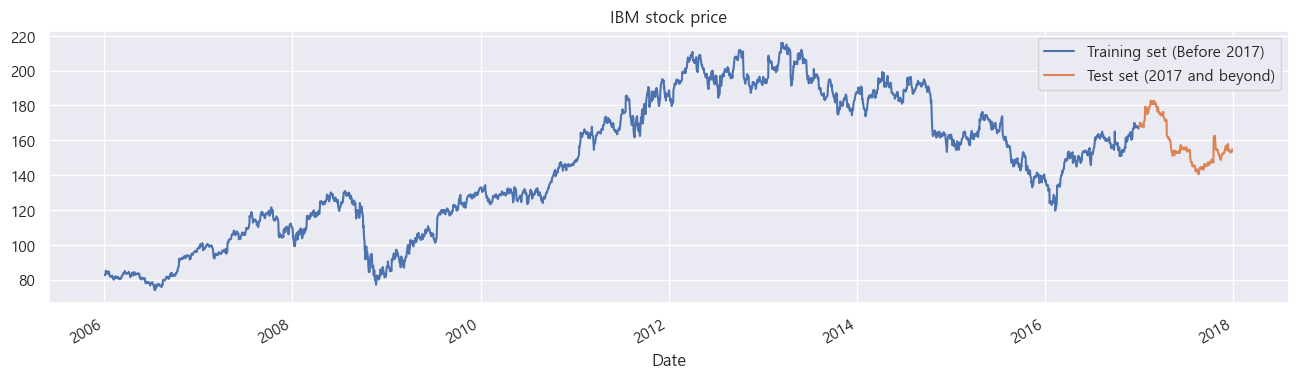

In [7]:
dataset["High"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["High"]['2017':].plot(figsize=(16,4),legend=True)

plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show();

## <b>전처리 & 가공

### train : 스케일링

In [8]:
training_set.shape, training_set[:2]

((2769, 1),
 array([[82.55],
        [82.5 ]]))

In [9]:
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set) #2차라서 ar.reshape(-1,1)필요없음
training_set_scaled[:3]

array([[0.06065089],
       [0.06029868],
       [0.06311637]])

### <b> train : 윈도우 슬라이딩
* window_size = 60
* (2769, 1) -> (2709, 60)

In [10]:
X_train = []
y_train = []

for i in range(60,2769):
    X_train.append(training_set_scaled[i-60:i,0])
    y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape, y_train.shape, X_train[:1])

(2709, 60) (2709,) [[0.06065089 0.06029868 0.06311637 0.0781206  0.07262609 0.07171034
  0.07657087 0.07058326 0.0669907  0.06494787 0.075796   0.07361229
  0.06417301 0.05621302 0.05783319 0.05409975 0.05431107 0.05515638
  0.05543815 0.05677656 0.05846717 0.05388842 0.04811214 0.04233587
  0.04402649 0.0490279  0.04832347 0.05297267 0.05614258 0.05290223
  0.05325444 0.04909834 0.04994365 0.04797126 0.05431107 0.05212736
  0.04726684 0.04895745 0.04656241 0.04839391 0.04416737 0.0485348
  0.04719639 0.04825303 0.05395886 0.05663567 0.05853762 0.05959425
  0.06375035 0.06917442 0.06889265 0.06670893 0.06910397 0.07783883
  0.07565511 0.07276698 0.06889265 0.0656523  0.06656805 0.06769513]]


위에랑 같은 코드
```python
X_train = []
y_train = []

window_size = 60

for i in range(0, 2769-window_size):
    X_train.append(training_set_scaled[i:i+window_size,0])
    y_train.append(training_set_scaled[i+window_size,0])

X_train, y_train = np.array(X_train), np.array(y_train)
print(X_train.shape, y_train.shape, X_train[:1])

위에 코드 = 과거 기준 미래 예측
지금코드 = 현재 기준으로 과거 사용

### <font color=red><b> train - input_shape : 3D
* samples : 데이터 갯수
* timestep : window_size
* features : 변수갯수 == df['cnt']

In [11]:
X_train = X_train.reshape(X_train.shape[0],   X_train.shape[1],     1)
                            #샘플수            #피쳐개수         #'high'변수
print(f"X_train.shape : {X_train.shape}") 
print(f"y_train.shape : {y_train.shape}") 
print(f"X_train[:1] ----------- \n  {X_train[:1]}")

X_train.shape : (2709, 60, 1)
y_train.shape : (2709,)
X_train[:1] ----------- 
  [[[0.06065089]
  [0.06029868]
  [0.06311637]
  [0.0781206 ]
  [0.07262609]
  [0.07171034]
  [0.07657087]
  [0.07058326]
  [0.0669907 ]
  [0.06494787]
  [0.075796  ]
  [0.07361229]
  [0.06417301]
  [0.05621302]
  [0.05783319]
  [0.05409975]
  [0.05431107]
  [0.05515638]
  [0.05543815]
  [0.05677656]
  [0.05846717]
  [0.05388842]
  [0.04811214]
  [0.04233587]
  [0.04402649]
  [0.0490279 ]
  [0.04832347]
  [0.05297267]
  [0.05614258]
  [0.05290223]
  [0.05325444]
  [0.04909834]
  [0.04994365]
  [0.04797126]
  [0.05431107]
  [0.05212736]
  [0.04726684]
  [0.04895745]
  [0.04656241]
  [0.04839391]
  [0.04416737]
  [0.0485348 ]
  [0.04719639]
  [0.04825303]
  [0.05395886]
  [0.05663567]
  [0.05853762]
  [0.05959425]
  [0.06375035]
  [0.06917442]
  [0.06889265]
  [0.06670893]
  [0.06910397]
  [0.07783883]
  [0.07565511]
  [0.07276698]
  [0.06889265]
  [0.0656523 ]
  [0.06656805]
  [0.06769513]]]


## <b> 모델 & 평가

In [12]:
# The LSTM architecture
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)) , #X_train.shape[1] == 60
    Dropout(0.2)  ,
    LSTM(units=50, return_sequences=True)  ,
    Dropout(0.2)  ,
    LSTM(units=50, return_sequences=True) ,
    Dropout(0.2) ,
    LSTM(units=50) ,
    Dropout(0.2) ,
    Dense(units=1)
])

model.compile(optimizer='adam',loss='mean_squared_error') #mean_squared_error == mse
fit_res = model.fit(X_train,y_train,epochs=10,batch_size=128)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 0.0531
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0082
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0057
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0048
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0048
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0048
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0043
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0043
Epoch 9/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0041
Epoch 10/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0043


```python
Epoch 50/50
2709/2709 [==============================] - 8s 3ms/step - loss: 0.0020

## <b>답안지 제출

In [13]:
#len(dataset), len(training_set), len(test_set), test_set.shape, len(inputs)

In [14]:
# 2006 ~ 2017전체 High컬럼 다시 합치기 -> 테스트 첫날 예측하려면 그 전 60일치 데이터 필요(train마지막 + test전체)
dataset_total = pd.concat((dataset["High"][:'2016'],dataset["High"]['2017':]),axis=0)

#len(training_set)가 251개이면 251개 예측을 위한 맨 앞 테스트 예측용 60일 데이터도 필요함
inputs = dataset_total[ len(dataset_total)-len(test_set) - 60: ].values 

inputs = inputs.reshape(-1,1) #MinMax는 2차원이라 2차원만들기
inputs[:10]
inputs  = sc.transform(inputs) #test데이터도 같은 스케일 변환
inputs.shape, inputs[:10]

array([[157.43],
       [157.7 ],
       [158.49],
       [156.95],
       [154.97],
       [154.22],
       [155.53],
       [155.89],
       [151.  ],
       [152.45]])

((311, 1),
 array([[0.58812342],
        [0.59002536],
        [0.59559031],
        [0.58474218],
        [0.57079459],
        [0.56551141],
        [0.57473936],
        [0.57727529],
        [0.54282897],
        [0.55304311]]))

### <b>test : 스케일링, 윈도우 슬라이딩
* window_size = 60
* train : (2769, 1) -> (2709, 60)
* test : (311, 1) ->)251,60)

In [15]:
X_test = []
window_size = 60
for i in range(0, 311-window_size): # 311-window_size == inputs 311 - window_size 60 = 251   == for i in range(0,251)
    X_test.append(inputs[i:i+window_size,0])
X_test = np.array(X_test)

print(X_test.shape, X_test[:1])

(251, 60) [[0.58812342 0.59002536 0.59559031 0.58474218 0.57079459 0.56551141
  0.57473936 0.57727529 0.54282897 0.55304311 0.55621302 0.5438856
  0.54649197 0.54395604 0.55649479 0.56438433 0.56706114 0.56628628
  0.5633277  0.55931248 0.56213018 0.56142575 0.57882502 0.57755706
  0.57495069 0.61439842 0.61566638 0.61932939 0.6002395  0.6030572
  0.60573401 0.61129896 0.62735982 0.62735982 0.62299239 0.62869822
  0.63905325 0.63729219 0.63299521 0.62172443 0.60826994 0.61432798
  0.61179205 0.64271626 0.64849253 0.65356438 0.65405748 0.67631727
  0.67589462 0.67561285 0.67040011 0.65736827 0.66434207 0.66215835
  0.66420118 0.65898845 0.66244012 0.66074951 0.65546633 0.6534235 ]]


### <font color=red><b>test - input_shape : 3D
* samples : 데이터 갯수
* timestep : window_size
* features : 변수갯수 == df['cnt']

In [16]:
X_test  = X_test.reshape(X_test.shape[0],   X_test.shape[1],     1)
X_test.shape

(251, 60, 1)

### test예측

In [17]:
pred_scale = model.predict(X_test)
pred = sc.inverse_transform(pred_scale)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step


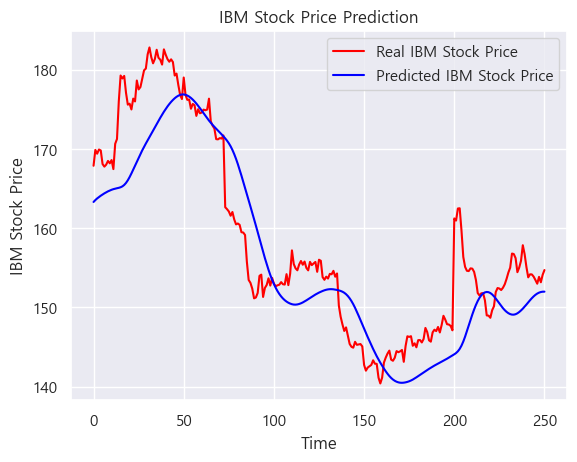

In [18]:
plot_predictions(test_set,pred)

In [19]:
return_rmse(test_set,pred)

The root mean squared error is 5.75610647578749.


In [20]:
dataset

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM
...,...,...,...,...,...,...
2017-12-22,151.82,153.00,151.50,152.50,2990583,IBM
2017-12-26,152.51,153.86,152.50,152.83,2479017,IBM
2017-12-27,152.95,153.18,152.61,153.13,2149257,IBM


우리는 epochs=10 낮게 잡음 그래서 점수가 2.9보다 낮음

* The root mean squared error is 2.8685362362359834.

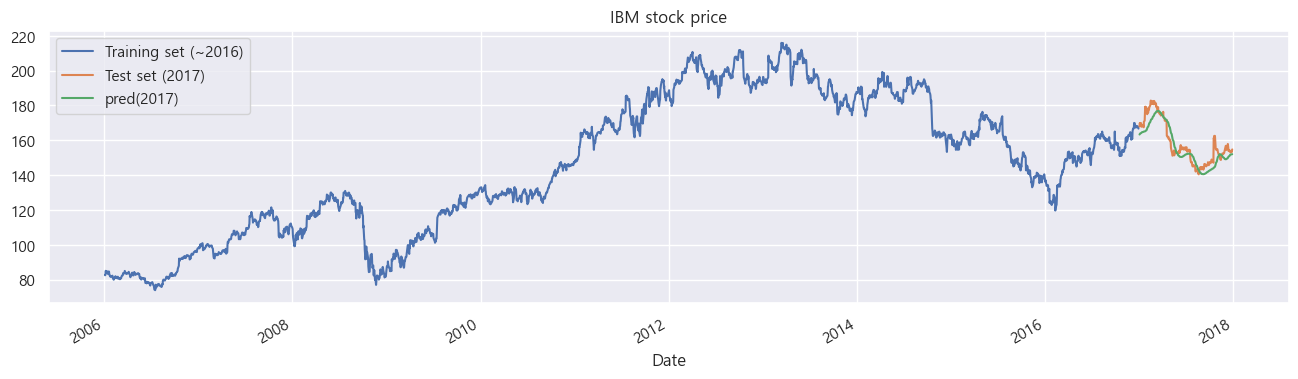

In [21]:
dataset["High"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["High"]['2017':].plot(figsize=(16,4),legend=True)
pd.DataFrame(pred, index=dataset["High"]['2017':].index)[0].plot(figsize=(16,4),legend=True)

plt.legend(['Training set (~2016)','Test set (2017)', 'pred(2017)'])
plt.title('IBM stock price')
plt.show();